## DSE 511 Final Project Cluster Analysis in Python
#### Jared Schlak
#### 2025-11-14

In [1]:
#Load the necessary libraries/packages

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from kmodes.kmodes import KModes
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [2]:
#Import Data from Step 1. Data Cleaning

# 1. Load the CSV file
clean_df = pd.read_csv('../../Step 1. Data Cleaning/Python code/outbreak_clean_v2.csv')

print(clean_df.head())
print(clean_df.info())
print(clean_df.describe())

   year  month        date  season       state state_abbr primary_mode  \
0  1971      2  1971-02-01  Winter  California         CA        Water   
1  1971      6  1971-06-01  Summer    Arkansas         AR        Water   
2  1971      6  1971-06-01  Summer    Missouri         MO        Water   
3  1971      6  1971-06-01  Summer     Alabama         AL        Water   
4  1971      6  1971-06-01  Summer     Vermont         VT        Water   

                    setting     etiology etiology_grouped  ... illnesses_std  \
0                Restaurant       Copper            Other  ...     -0.019976   
1                     Store  Hepatitis A        Hepatitis  ...      0.041387   
2  Subdivision/Neighborhood      Unknown          Unknown  ...     -0.019976   
3                   Unknown     Selenium            Other  ...     -0.019336   
4    Community/municipality      Unknown          Unknown  ...     -0.019336   

  hospitalizations_std deaths_std hosp_per_ill death_per_ill  \
0         

### Create different features such as Region and Setting_grouped

In [4]:
# --- 1. Define the regions and their respective states ---

northeast_states = [
    "Connecticut", "Maine", "Massachusetts", "New Hampshire",
    "Rhode Island", "Vermont", "New Jersey", "New York", "Pennsylvania"
]

midwest_states = [
    "Illinois", "Indiana", "Michigan", "Ohio", "Wisconsin",
    "Iowa", "Kansas", "Minnesota", "Missouri", "Nebraska",
    "North Dakota", "South Dakota"
]

south_states = [
    "Delaware", "District of Columbia", "Florida", "Georgia",
    "Maryland", "North Carolina", "South Carolina", "Virginia",
    "West Virginia",
    "Alabama", "Kentucky", "Mississippi", "Tennessee",
    "Arkansas", "Louisiana", "Oklahoma", "Texas"
]

west_states = [
    "Arizona", "Colorado", "Idaho", "Montana", "Nevada",
    "New Mexico", "Utah", "Wyoming",
    "Alaska", "California", "Hawaii", "Oregon",
    "Washington"
]

territory_states = [
    "Puerto Rico", "Guam", "Northern Mariana Islands",
    "Virgin Islands", "Republic of Palau",
    "Republic of the Marshall Islands"
]

# --- 2. Define conditions and corresponding choices for numpy.select ---

# The conditions are boolean Series generated by checking if the 'State' value is in the list
conditions = [
    # Northeast
    clean_df['state'].isin(northeast_states),
    # Midwest
    clean_df['state'].isin(midwest_states),
    # South
    clean_df['state'].isin(south_states),
    # West
    clean_df['state'].isin(west_states),
    # Territories
    clean_df['state'].isin(territory_states),
    # Multistate special case
    clean_df['state'] == "Multistate"
]

# The corresponding values for the new column 'Region'
choices = [
    "Northeast",
    "Midwest",
    "South",
    "West",
    "Territory",
    "Multistate"
]

# --- 3. Apply the conditions to create the new 'Region' column ---

clean_df['region'] = np.select(conditions, choices, default='Other')

# --- Optional: Verification (Equivalent to a count/table) ---
print(clean_df['region'].value_counts())

region
Midwest       21492
South         16546
West          13964
Northeast     13334
Multistate     1069
Territory       301
Name: count, dtype: int64


In [8]:
# --- 1. Define the regular expression patterns for each group ---

# Food Service
food_service_pattern = "Restaurant|Caterer|Grocery|Store"

# Home/Residential
home_pattern = "Private home|Apartment|Mobile home|residence"

# Healthcare
healthcare_pattern = "Hospital|nursing home|assisted living|long-term care"

# Education
education_pattern = "School|college|university|daycare|preschool"

# Workplace/Industrial
workplace_pattern = "Factory|industrial|workplace|Place of Work"

# Community/Public Facilities
community_pattern = "Community|municipality|Subdivision|Hall|Fee-based|Correctional|detention|Native American"

# Recreation / Parks / Outdoors
recreation_pattern = "Park|Resort|Hotel|Beach|Camp|cabin|Backcountry|wilderness|Zoo|Festival|Fair"

# Unknown / Missing
unknown_pattern = "Unknown"

# --- 2. Define conditions and corresponding choices for numpy.select ---

# The conditions are boolean Series generated by checking if the 'Setting' column contains the pattern (case-insensitive)
conditions = [
    # Food Service
    clean_df['setting'].str.contains(food_service_pattern, case=False, na=False),

    # Home/Residential
    clean_df['setting'].str.contains(home_pattern, case=False, na=False),

    # Healthcare
    clean_df['setting'].str.contains(healthcare_pattern, case=False, na=False),

    # Education
    clean_df['setting'].str.contains(education_pattern, case=False, na=False),

    # Workplace/Industrial
    clean_df['setting'].str.contains(workplace_pattern, case=False, na=False),

    # Community/Public Facilities
    clean_df['setting'].str.contains(community_pattern, case=False, na=False),

    # Recreation / Parks / Outdoors
    clean_df['setting'].str.contains(recreation_pattern, case=False, na=False),

    # Unknown / Missing
    clean_df['setting'].str.contains(unknown_pattern, case=False, na=False)
]

choices = [
    "Food Service",
    "Home/Residential",
    "Healthcare",
    "Education",
    "Workplace/Industrial",
    "Community/Public",
    "Recreation/Outdoors",
    "Unknown"
]

# --- 3. Apply the conditions to create the new 'Setting_group' column ---

# This is equivalent to the R mutate() + case_when().
# The 'default' argument handles the R 'TRUE ~ "Other"' case.
clean_df['setting_grouped'] = np.select(conditions, choices, default='Other')

# --- Optional: Verification (Equivalent to a count/table) ---
print(clean_df['setting_grouped'].value_counts())

setting_grouped
Healthcare              22568
Food Service            18372
Education                7585
Unknown                  6879
Other                    4139
Home/Residential         3794
Recreation/Outdoors      2013
Community/Public         1048
Workplace/Industrial      308
Name: count, dtype: int64


In [9]:
missing_value_summary = clean_df[[
    'date',
    'season',
    'region',
    'primary_mode',
    'setting_grouped',
    'etiology_grouped'
]].isna().sum()


print(missing_value_summary)

date                0
season              0
region              0
primary_mode        0
setting_grouped     0
etiology_grouped    0
dtype: int64


### Cluster Analysis

#### K-Means

##### I needed to remove the largest outlier in this dataset for K-means to function well, otherwise we would have one cluster that only has one data point in it.

##### I decided to do K-means analysis on three features:  year, month, and illnesses.  This would try to group the data by the time period in years and also by month and then connect that to the number of illnesses.  We can see later if this would help us see how the seriousness of the illness connected to the time of year.

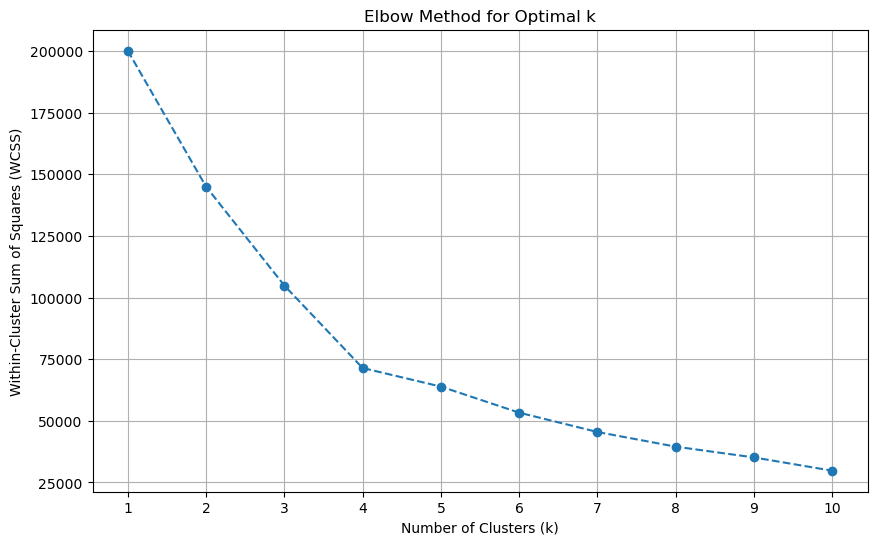

WCSS values for k=1 to 10:
1     200115.000000
2     144992.979861
3     104869.539602
4      71413.989456
5      63868.863918
6      53293.364447
7      45451.655074
8      39499.420388
9      35137.297201
10     29744.155892
dtype: float64


In [44]:
df_no_outlier = clean_df.drop(index=870)

# Your specified features
features = ['year', 'month', 'illnesses']
X = df_no_outlier[features]

# 1. Z-transformation (Standard Scaling)
# Standard Scaler performs the Z-transformation: (x - mean) / standard deviation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Elbow Method with WCSS (Inertia)
wcss = []
k_range = range(1, 11)
random_seed = 511 # Set seed for reproducibility, as requested

for i in k_range:
    # Initialize K-Means with the specified seed and k value
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=random_seed, n_init='auto')
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_) # .inertia_ is the WCSS

# 3. Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(k_range, wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.grid(True)
plt.xticks(k_range)
plt.show()

# Print WCSS values to help with elbow determination
print("WCSS values for k=1 to 10:")
print(pd.Series(wcss, index=k_range))

##### As you can see from the above graph using the elbow method, I ended up deciding to go with 4 clusters as you can see that it is the best "Elbow" for our data.

In [52]:
# Define the k values you want to test
k_values_to_test = [2, 3, 4, 5, 6]
random_seed = 123 # Keep the seed for reproducibility

print("Fitting K-Means models for k=2-6")
print("-" * 40)

for k in k_values_to_test:
    # 1. Initialize the K-Means model
    kmeans_k = KMeans(
        n_clusters=k,
        init='k-means++',
        random_state=random_seed,
        n_init='auto'
    )

    # 2. Fit and predict the cluster labels
    # Assign labels to a new column specific to that k (e.g., 'Cluster_k3')
    column_name = f'Cluster_k{k}'
    df_no_outlier[column_name] = kmeans_k.fit_predict(X_scaled)

    # 3. Print the results for this k
    print(f"\nCluster Sizes for k={k}:")
    print(df_no_outlier[column_name].value_counts())
    print("-" * 40)

Fitting K-Means models for k=2-6
----------------------------------------

Cluster Sizes for k=2:
Cluster_k2
0    66690
1       15
Name: count, dtype: int64
----------------------------------------

Cluster Sizes for k=3:
Cluster_k3
2    33960
0    19369
1    13376
Name: count, dtype: int64
----------------------------------------

Cluster Sizes for k=4:
Cluster_k4
2    22197
0    18702
3    16144
1     9662
Name: count, dtype: int64
----------------------------------------

Cluster Sizes for k=5:
Cluster_k5
2    21778
0    18484
3    16539
1     9894
4       10
Name: count, dtype: int64
----------------------------------------

Cluster Sizes for k=6:
Cluster_k6
2    21559
0    18471
3    16657
1     9977
5       37
4        4
Name: count, dtype: int64
----------------------------------------


Generating plots for k=4 using existing column: Cluster_4...


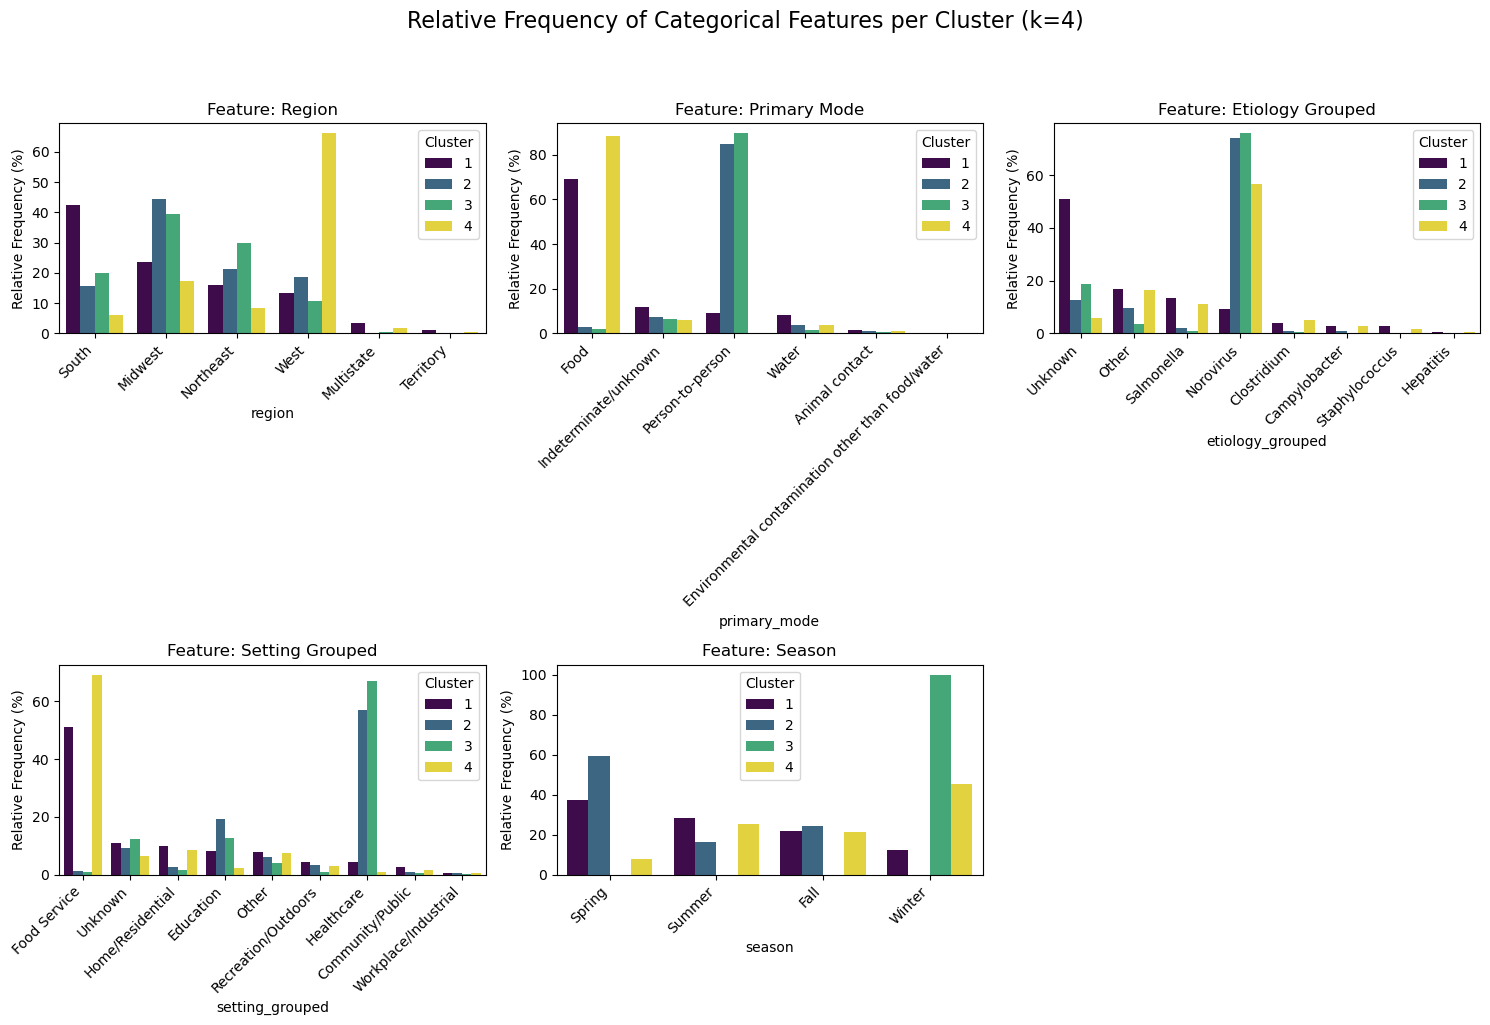

In [53]:
def plot_cluster_relative_frequencies_final(df_to_plot, cluster_column_name, categorical_features, df_for_nunique):
    """
    Generates bar plots showing the relative frequency of the specified categorical 
    features within each cluster.
    """
    
    # NOTE: num_clusters is derived from the existing column in the DataFrame
    num_clusters = df_for_nunique[cluster_column_name].nunique()
    
    # Use the input list directly
    features_to_plot = categorical_features 
    n_features = len(features_to_plot)
    n_cols = 3 
    n_rows = (n_features + n_cols - 1) // n_cols

    plt.figure(figsize=(n_cols * 5, n_rows * 5))
    plt.suptitle(f'Relative Frequency of Categorical Features per Cluster (k={num_clusters})', 
                 fontsize=16, y=1.02)
    
    # Iterate through each specified categorical feature
    for i, feature in enumerate(features_to_plot):
        plt.subplot(n_rows, n_cols, i + 1)
        
        # Calculate the relative frequency (proportions)
        proportions = df_to_plot.groupby(cluster_column_name)[feature].value_counts(normalize=True).mul(100).rename('Percent').reset_index()

        # --- PLOTTING ---
        sns.barplot(
            x=feature, 
            y='Percent', 
            hue=cluster_column_name, 
            data=proportions,
            palette='viridis'
        )
        
        plt.title(f'Feature: {feature.replace("_", " ").title()}')
        plt.ylabel('Relative Frequency (%)')
        plt.xticks(rotation=45, ha='right')
        plt.legend(title='Cluster')
        plt.tight_layout(rect=[0, 0, 1, 0.98])

    plt.show()

# --- INPUTS AND EXECUTION ---
# The below features are used
categorical_features_final = [
    'region',           
    'primary_mode',       
    'etiology_grouped',
    'setting_grouped', 
    'season'
]

# Decided that 4 clusters was the best number of clusters!
cluster_k_name = 'Cluster_4'

print(f"Generating plots for k=4 using existing column: {cluster_k_name}...")
plot_cluster_relative_frequencies_final(df_no_outlier, cluster_k_name, categorical_features_final, df_no_outlier)

#### K-Modes
##### This is a grouping or clustering algorithm used for categorical variables. We will be using the following categories to group the clusters by:
##### Date, Season, Region, Primary_mode, Setting_grouped, and Etiology_grouped

In [15]:
kmodes_df = clean_df[[
    'date',
    'season',
    'region',
    'primary_mode',
    'setting_grouped',
    'etiology_grouped'
]].astype('category')

# Print the first few rows to verify the columns
print(kmodes_df.head())
print(kmodes_df.shape)

         date  season     region primary_mode   setting_grouped  \
0  1971-02-01  Winter       West        Water      Food Service   
1  1971-06-01  Summer      South        Water      Food Service   
2  1971-06-01  Summer    Midwest        Water  Community/Public   
3  1971-06-01  Summer      South        Water           Unknown   
4  1971-06-01  Summer  Northeast        Water  Community/Public   

  etiology_grouped  
0            Other  
1        Hepatitis  
2          Unknown  
3            Other  
4          Unknown  
(66706, 6)


In [16]:
# print summary of the new kmodes_df
summary = kmodes_df.describe(include='category')
print(summary)

# Check for null values in each column
missing_counts = kmodes_df.isna().sum()
print(missing_counts)


              date  season   region      primary_mode setting_grouped  \
count        66706   66706    66706             66706           66706   
unique         599       4        6                 6               9   
top     2017-01-01  Winter  Midwest  Person-to-person      Healthcare   
freq           798   24608    21492             32414           22568   

       etiology_grouped  
count             66706  
unique                8  
top           Norovirus  
freq              33157  
date                0
season              0
region              0
primary_mode        0
setting_grouped     0
etiology_grouped    0
dtype: int64


### Determining the number of clusters using the Elbow Method

In [18]:
# 1. Set the random seed for reproducibility
np.random.seed(123)

# 2. Define the input data
kmodes_input_array = kmodes_df.values

# 3. Create an empty dictionary to store results 
kmodes_results = {}

# 4. Run K-modes on clusters from size 1-10
for k in range(1, 11):
    print(f"Fitting k = {k}")

    # Initialize the KModes model

    km = KModes(
        n_clusters=k, 
        init='Huang',
        max_iter=50, 
        verbose=0
    )

    # Fit the model and get the cost (dissimilarity/inertia)
    # The fit() method returns the model object, which is stored in the dictionary.
    km.fit(kmodes_input_array)
    
    # Store the fitted model object and the cost
    kmodes_results[f'k_{k}'] = {
        'model': km,
        'cost': km.cost_
    }

# Sanity check: Print the costs
print("\n--- K-Modes Costs ---")
for k, result in kmodes_results.items():
    print(f"{k}: Cost = {result['cost']:.2f}")

Fitting k = 1
Fitting k = 2
Fitting k = 3
Fitting k = 4
Fitting k = 5
Fitting k = 6
Fitting k = 7
Fitting k = 8
Fitting k = 9
Fitting k = 10

--- K-Modes Costs ---
k_1: Cost = 265199.00
k_2: Cost = 213908.00
k_3: Cost = 202711.00
k_4: Cost = 191410.00
k_5: Cost = 184272.00
k_6: Cost = 180592.00
k_7: Cost = 174523.00
k_8: Cost = 172289.00
k_9: Cost = 169094.00
k_10: Cost = 165078.00


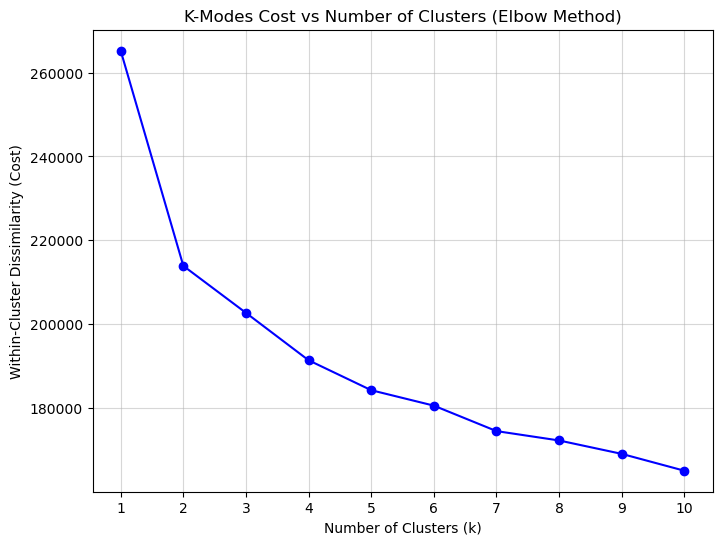

In [21]:
import matplotlib.pyplot as plt

# --- Extract within-cluster dissimilarities (cost) by cluster size ---
k_range = range(1, 11)
kmodes_costs = [kmodes_results[f'k_{k}']['cost'] for k in k_range]

# --- Plot the Elbow curve ---

plt.figure(figsize=(8, 6))
plt.plot(
    list(k_range),
    kmodes_costs,
    marker='o',        
    linestyle='-',      
    color='blue'
)
plt.title("K-Modes Cost vs Number of Clusters (Elbow Method)")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Within-Cluster Dissimilarity (Cost)")
plt.xticks(list(k_range))
plt.grid(True, alpha=0.5)

plt.show
plt.savefig('kmodes_elbow_plot.png')

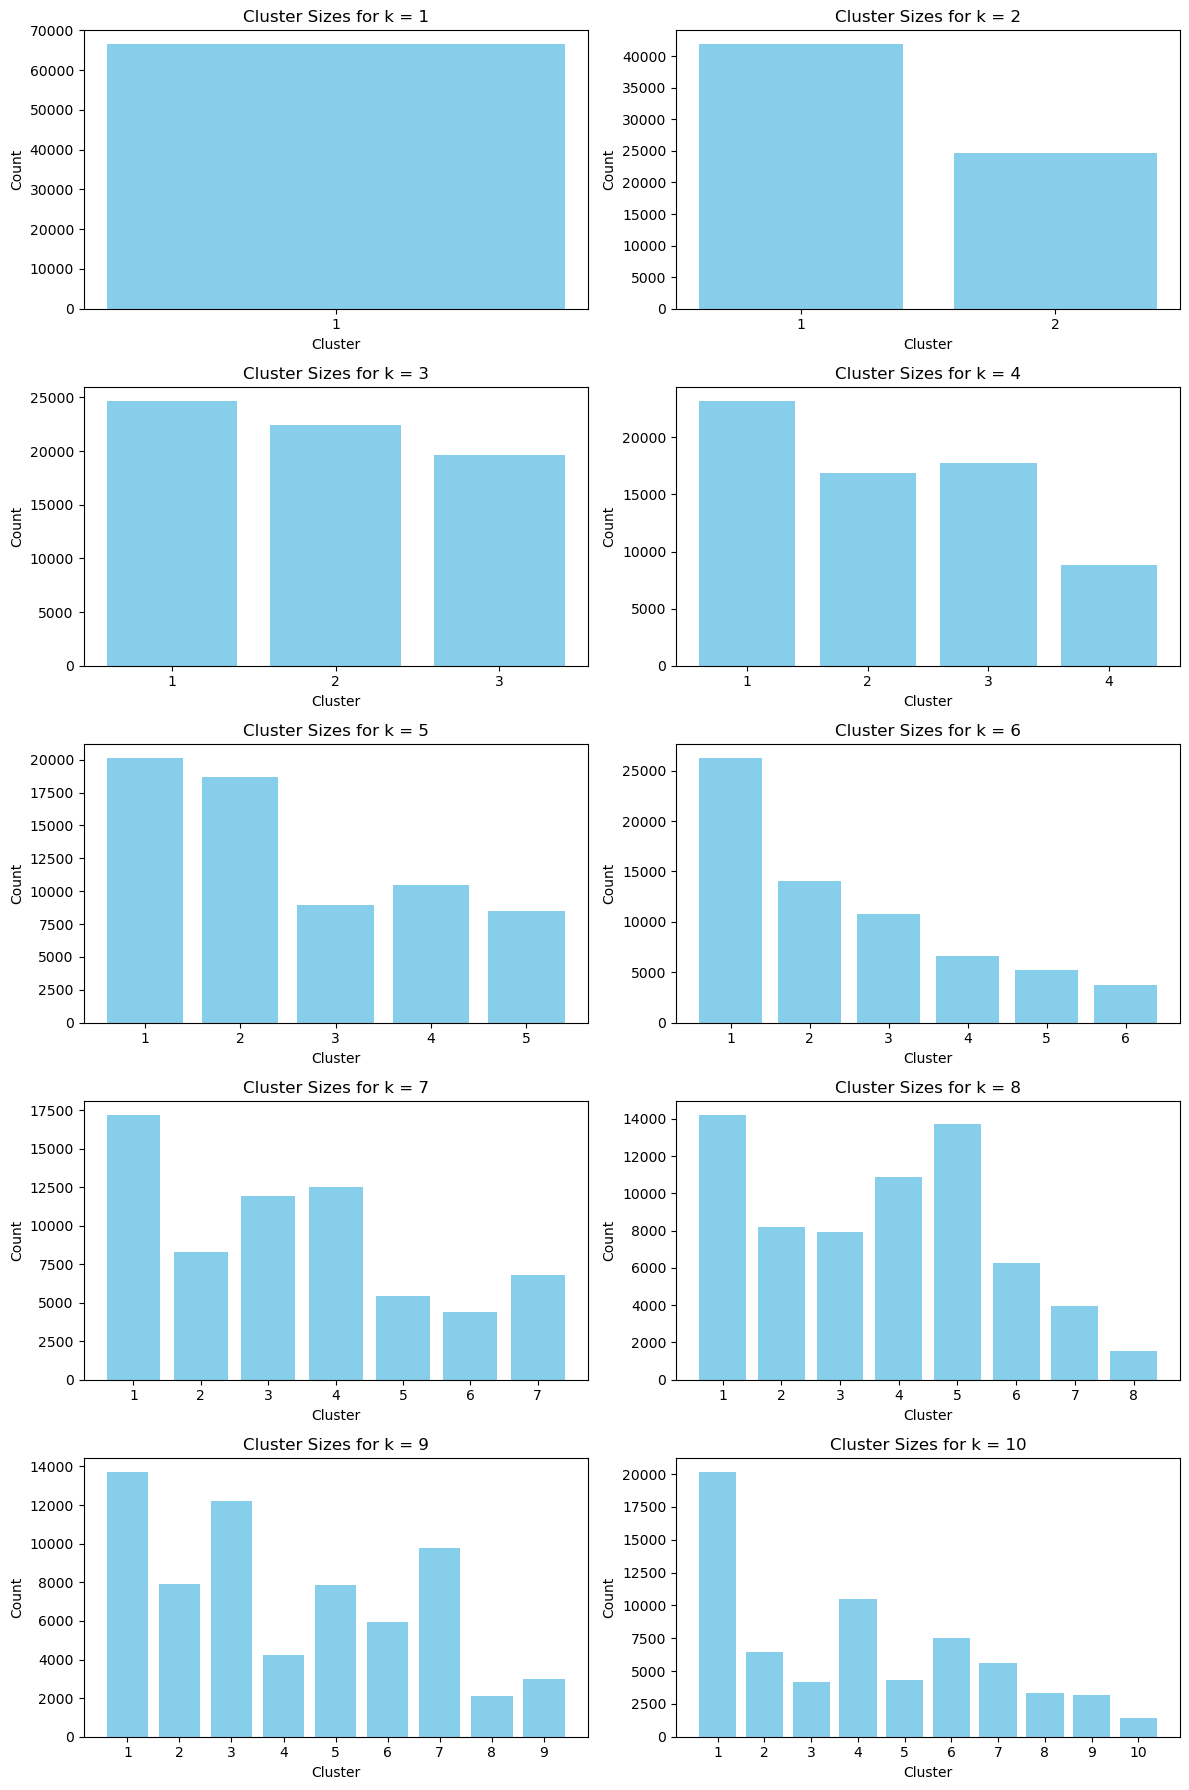

In [22]:
# --- 1. Extract cluster size counts ---

k_range = range(1, 11)
cluster_sizes_counts = {}

for k in k_range:

    km_model = kmodes_results[f'k_{k}']['model']

    cluster_sizes_counts[k] = pd.Series(km_model.labels_).value_counts().sort_index().to_dict()

# --- 2. Plotting each cluster size table ---

fig, axes = plt.subplots(5, 2, figsize=(12, 18))
axes = axes.flatten()

for i, k in enumerate(k_range):
    ax = axes[i]

    sizes = cluster_sizes_counts[k]
    clusters = [str(c + 1) for c in sizes.keys()] 
    counts = list(sizes.values())
    
    ax.bar(
        clusters,
        counts,
        color='skyblue'
    )
    
    ax.set_title(f"Cluster Sizes for k = {k}")
    ax.set_xlabel("Cluster")
    ax.set_ylabel("Count")

for j in range(len(k_range), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()

plt.show()

#### From the graphs above I really like the clusters when k = 4.  They are pretty similar in size and their cost is pretty low in the graph above for the elbow method.

In [23]:
# 1. Select the fitted model for k=4

optimal_k = 4
km_optimal = kmodes_results[f'k_{optimal_k}']['model']

# 2. Get the cluster labels (predictions)

cluster_labels = km_optimal.labels_

# 3. Add the new column to your main DataFrame (clean_df)

clean_df['Cluster_4'] = cluster_labels + 1

# Optional: Verify the clusters were added and count their sizes
print("✅ Cluster labels added to clean_df.")
print("\nCluster Size Distribution:")
print(clean_df['Cluster_4'].value_counts().sort_index())

✅ Cluster labels added to clean_df.

Cluster Size Distribution:
Cluster_4
1    23217
2    16908
3    17720
4     8861
Name: count, dtype: int64


### Now we can start to visualize our data!

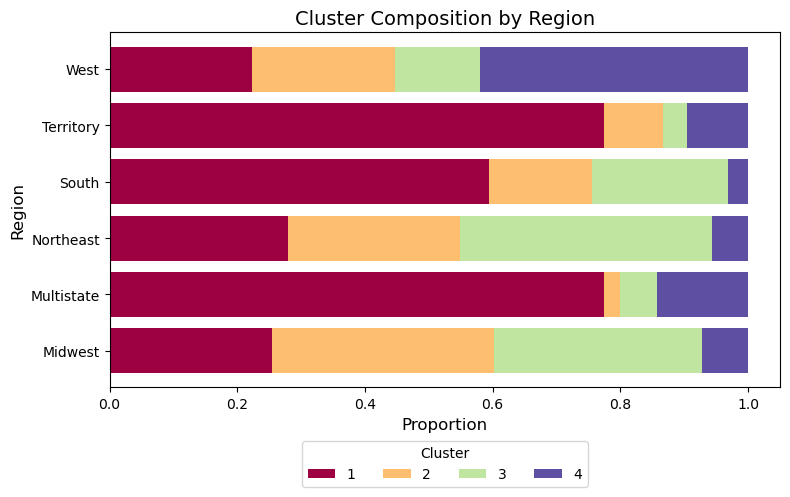

In [27]:
def plot_cluster_comp(data, var_name):
    """
    Generates a normalized, stacked bar plot showing the proportion of 
    clusters within each category of the specified variable.
    Args:
        data (pd.DataFrame): The DataFrame containing the cluster column 
                             and the feature columns.
        var_name (str): The name of the categorical column to analyze 
                        (e.g., 'Region', 'Season').
    """
    
    # 1. Create a cross-tabulation of the variable vs. cluster
    # Index is the feature (Region), Columns are the clusters
    crosstab = pd.crosstab(data[var_name], data['Cluster_4'])
    
    # 2. Normalize the crosstab to get proportions (sum of each row = 1)
    crosstab_normalized = crosstab.div(crosstab.sum(axis=1), axis=0)
    
    # 3. Create the stacked bar plot (and transpose it for the horizontal view)
    ax = crosstab_normalized.plot(
        kind='barh', 
        stacked=True,
        figsize=(8, 6),
        width=0.8,
        cmap='Spectral'
    )
    
    # 4. Set plot aesthetics
    title = f"Cluster Composition by {var_name.replace('_', ' ').title()}"
    ax.set_title(title, fontsize=14)
    ax.set_xlabel("Proportion", fontsize=12)
    ax.set_ylabel(var_name.replace('_', ' ').title(), fontsize=12)
    
    # Set legend position
    ax.legend(title='Cluster', loc='lower center', bbox_to_anchor=(0.5, -0.3), ncol=len(crosstab.columns))
    
    # Show the plot
    plt.tight_layout(rect=[0, 0.1, 1, 1])
    plt.show()

plot_cluster_comp(clean_df, "region") 

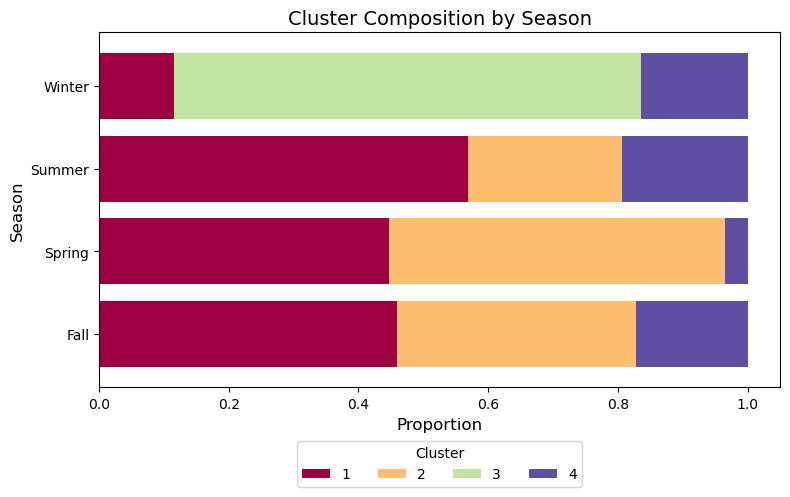

In [28]:
# Plot it for season
plot_cluster_comp(clean_df, "season")

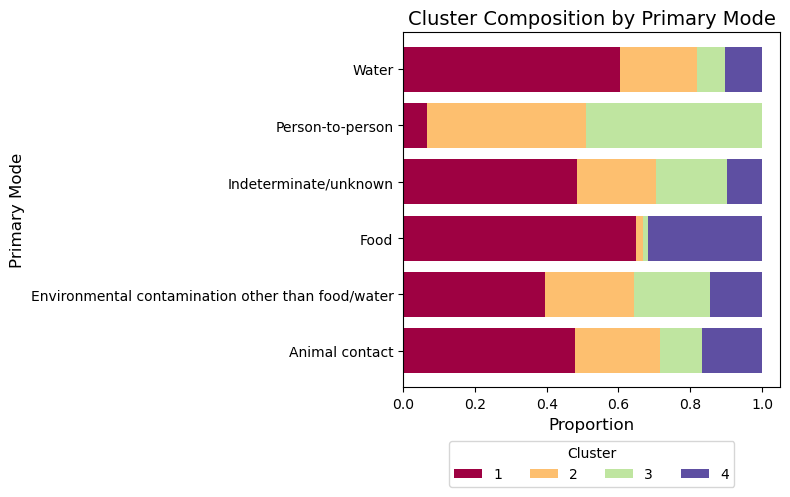

In [29]:
# Plot it for Primary Mode
plot_cluster_comp(clean_df, "primary_mode")

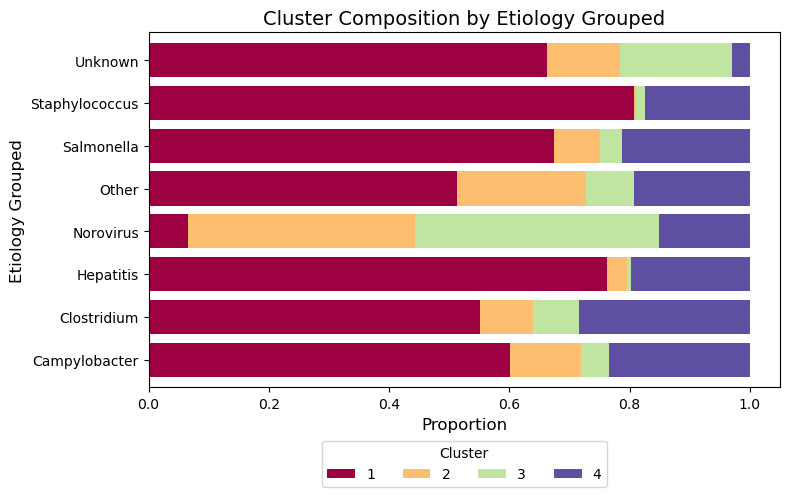

In [30]:
# Plot it for Etiology Group
plot_cluster_comp(clean_df, "etiology_grouped")

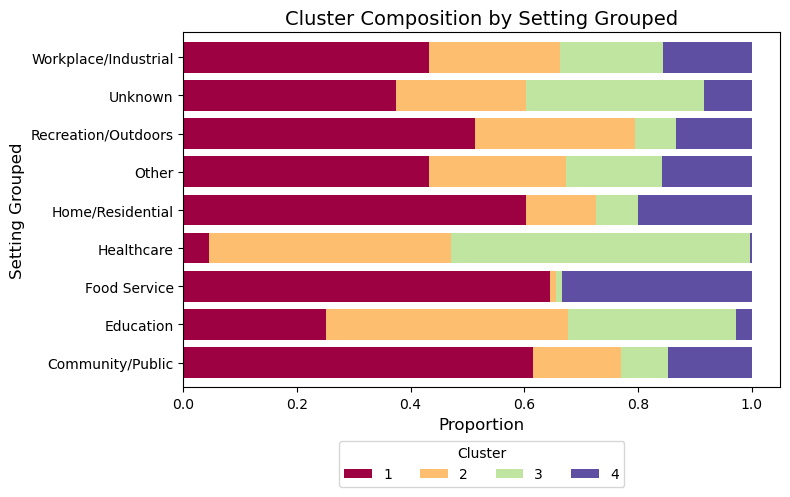

In [31]:
# Plot it for Setting Group
plot_cluster_comp(clean_df, "setting_grouped")